## AI x Semiconductor Industry Analysis

Goal: demand vs production, geopolitical risk, regional potential, market economics across 1990–2046

In [29]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

### Configuration - morandi color & global style

Assign each thematic role a stable color so charts stay visually coherent

In [39]:
MORANDI = {
    "sage":        "#8FA68E",   # production / supply
    "dusty_blue":  "#7A9BB5",   # demand / AI
    "blush":       "#C4917A",   # risk / disruption
    "mauve":       "#A68FA6",   # geopolitical
    "warm_sand":   "#C4B49A",   # economics / revenue
    "steel":       "#8FA6B5",   # trade / logistics
    "rose_gray":   "#B5A0A0",   # automotive
    "moss":        "#99A882",   # Southeast Asia / growth
    "clay":        "#B58C7A",   # East Asia
    "lavender":    "#A09AB5",   # Europe / innovation
    "cream":       "#D4C9B8",   # neutral / background accent
    "charcoal":    "#4A4A4A",   # text
}

# Snapshot years - compare throughout the analysis (focus now and future)
SNAPSHOT_YEARS = [2016, 2026, 2036]

# Region color mapping
REGION_COLORS = {
    "East Asia":      MORANDI["clay"],
    "North America":  MORANDI["dusty_blue"],
    "Europe":         MORANDI["lavender"],
    "Southeast Asia": MORANDI["moss"],
    "South Asia":     MORANDI["warm_sand"],
    "Middle East":    MORANDI["blush"],
    "Other":          MORANDI["cream"],
}

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   10,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "figure.facecolor": "#FAFAF8",
    "axes.facecolor":   "#FAFAF8",
    "legend.framealpha":0.6,
    "legend.fontsize":  9,
})

### I. Load Data

Each CSV covers a different lens:

1. production capacity
2. AI hardware demand,trade flows
3. technology innovation
4. geopolitical risk
5. supply disruption
6. market economics

In [40]:
BASE = "/content/sample_data/"   # using local colab

df_prod    = pd.read_csv(BASE + "1_semiconductor_production.csv")
df_ai      = pd.read_csv(BASE + "2_ai_hardware_demand.csv")
df_trade   = pd.read_csv(BASE + "3_semiconductor_trade_supply_chain.csv")
df_tech    = pd.read_csv(BASE + "4_technology_node_innovation.csv")
df_geo     = pd.read_csv(BASE + "5_geopolitical_risk_sanctions.csv")
df_supply  = pd.read_csv(BASE + "6_supply_chain_disruption.csv")
df_market  = pd.read_csv(BASE + "7_semiconductor_market_economics.csv")

print("Done")


Done


### II. EDA

Before diving into visualization, print shape, date range and missing-value counts - make sure that we understand, summarize and visualize a dataset before formal modeling, ensuring data quality, identifying underlying patterns, and detecting outliers

In [41]:
datasets = {
    "1_semiconductor_production":  df_prod,
    "2_ai_hardware_demand":        df_ai,
    "3_trade_supply_chain":        df_trade,
    "4_technology_node_innovation":df_tech,
    "5_geopolitical_risk":         df_geo,
    "6_supply_chain_disruption":   df_supply,
    "7_market_economics":          df_market,
}

print("EDA Summary")
for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    years   = f"{df['Year'].min()}–{df['Year'].max()}"
    print(f"\n {name}")
    print(f"   Rows: {len(df):,}  |  Columns: {df.shape[1]}  |  Years: {years}  |  Missing: {missing}")
    print(f"   Columns: {list(df.columns)}")

def snapshot(df, year_col="Year"):
    return df[df[year_col].isin(SNAPSHOT_YEARS)].copy()

EDA Summary

 1_semiconductor_production
   Rows: 2,282  |  Columns: 9  |  Years: 1990–2036  |  Missing: 0
   Columns: ['Year', 'Country', 'Company', 'Production_Capacity_Wafers', 'Fab_Count', 'Technology_Node_nm', 'AI_Chip_Production', 'Foundry_Revenue_USD', 'Global_Market_Share']

 2_ai_hardware_demand
   Rows: 1,880  |  Columns: 8  |  Years: 1990–2036  |  Missing: 0
   Columns: ['Year', 'Country', 'AI_GPU_Demand', 'Data_Center_Count', 'AI_Compute_Power', 'Cloud_AI_Investment', 'Training_Compute_FLOPS', 'AI_Model_Count']

 3_trade_supply_chain
   Rows: 3,948  |  Columns: 8  |  Years: 1990–2036  |  Missing: 0
   Columns: ['Year', 'Exporting_Country', 'Importing_Country', 'Chip_Export_Value_USD', 'Chip_Import_Value_USD', 'Trade_Balance', 'Logistics_Route', 'Supply_Chain_Dependency']

 4_technology_node_innovation
   Rows: 2,282  |  Columns: 8  |  Years: 1990–2036  |  Missing: 0
   Columns: ['Year', 'Company', 'Node_Size_nm', 'Transistor_Density', 'RD_Spending_USD', 'Patent_Count', 'AI_

### III. Demand vs Production Gap (2026 / 2036 / 2046)

Gap between AI chip demand and actual production capacity reveals \
Determine/To find out: whether the industry is `Supply-Constrained` or `Demand-Constrained`
1. A growing gap signals investment urgency
2. A closing gap shows market maturity

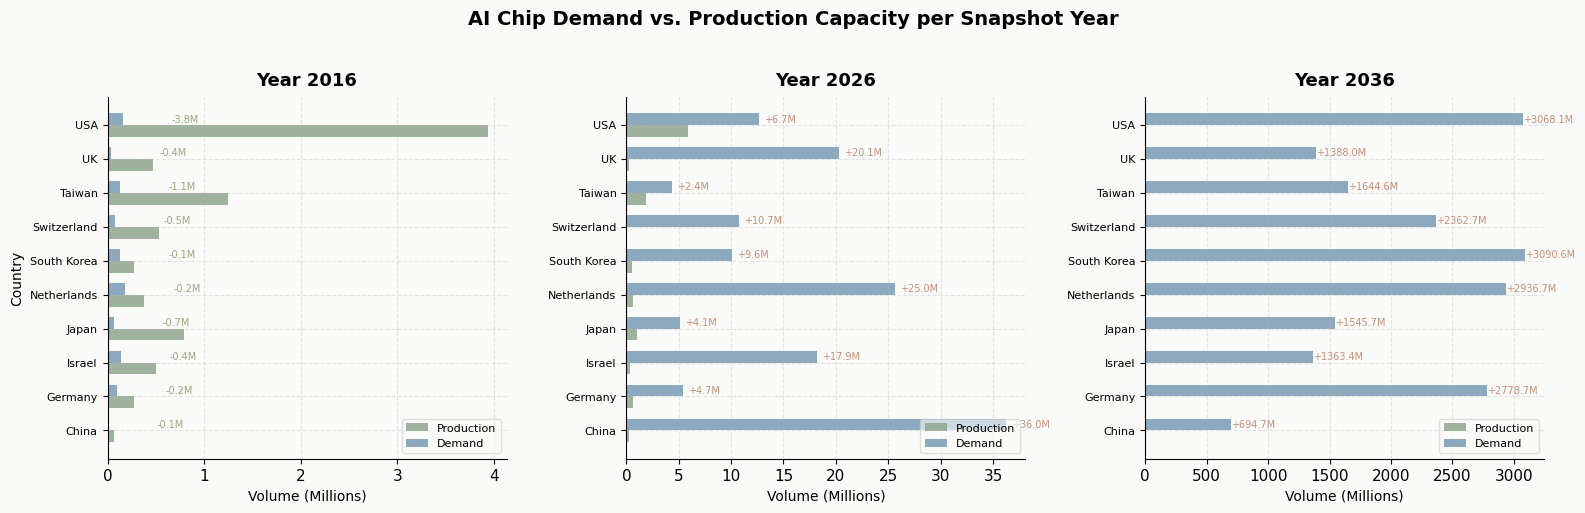

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle(
    "AI Chip Demand vs. Production Capacity per Snapshot Year",
    fontsize=14, fontweight="bold", y=1.02
)

for ax, yr in zip(axes, SNAPSHOT_YEARS):

    # Production side: total AI chip production by country (2026 / 2036 / 2046)
    prod_yr = df_prod[df_prod["Year"] == yr].groupby("Country")["AI_Chip_Production"].sum()

    # Demand side: total AI GPU demand by country (2026 / 2036 / 2046)
    dem_yr  = df_ai[df_ai["Year"] == yr].groupby("Country")["AI_GPU_Demand"].sum()

    # Align on shared countries
    countries = prod_yr.index.intersection(dem_yr.index)
    prod_vals = prod_yr[countries].values / 1e6   # scale to millions
    dem_vals  = dem_yr[countries].values  / 1e6

    # Gap = demand − production (positive = under-supplied)
    gap = dem_vals - prod_vals

    y_pos = np.arange(len(countries))
    bar_h = 0.35

    bars_p = ax.barh(y_pos - bar_h/2, prod_vals, bar_h,
                     label="Production", color=MORANDI["sage"],   alpha=0.85)
    bars_d = ax.barh(y_pos + bar_h/2, dem_vals,  bar_h,
                     label="Demand",     color=MORANDI["dusty_blue"], alpha=0.85)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(countries, fontsize=8)
    ax.set_title(f"Year {yr}", pad=8)
    ax.set_xlabel("Volume (Millions)")
    ax.legend(loc="lower right", fontsize=8)

    # Annotate gap on the demand bar
    for i, (g, dv) in enumerate(zip(gap, dem_vals)):
        color = MORANDI["blush"] if g > 0 else MORANDI["moss"]
        label = f"+{g:.1f}M" if g > 0 else f"{g:.1f}M"
        ax.text(dv + 0.5, i + bar_h/2, label, va="center", fontsize=7, color=color)

axes[0].set_ylabel("Country")
plt.tight_layout()
plt.savefig("chart1_demand_vs_production.png", dpi=150, bbox_inches="tight")
plt.show()


### IV. Supply Chain Risk over Time by Region

Goal: to understand how risk has evolved historically - tells us which regions are structurally fragile \
Formula: \
`High_Supply_Disruption_Index `= higher chance of chip shortages, price spikes, or delivery failures

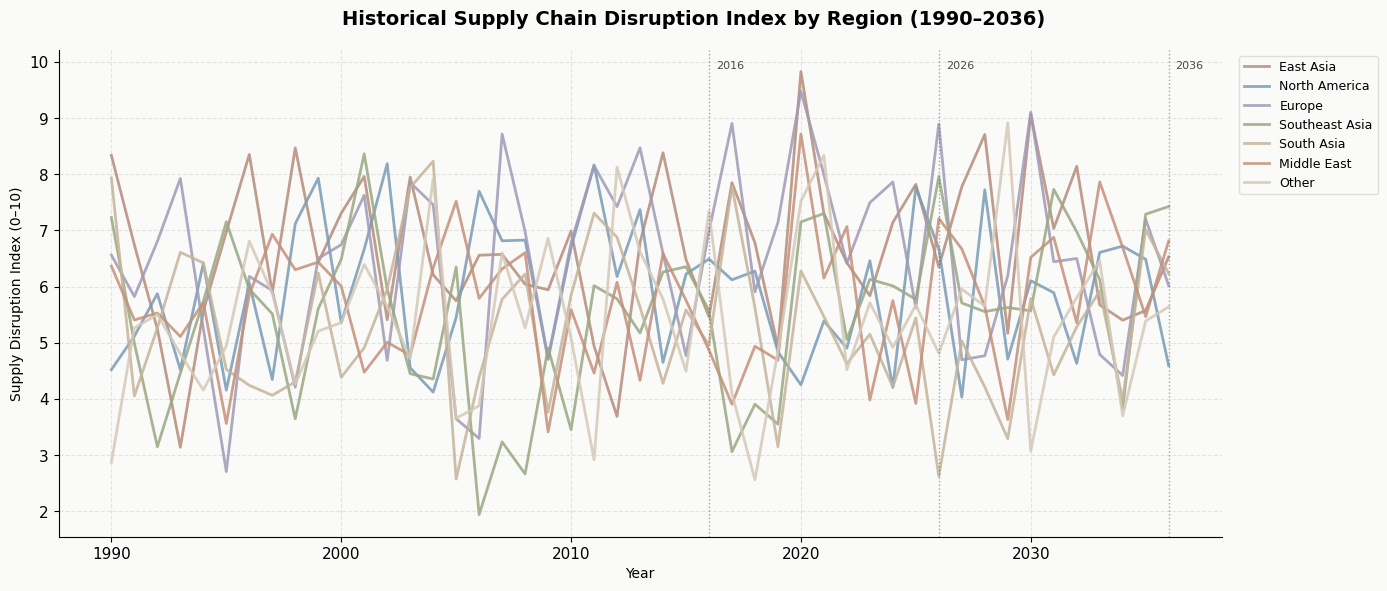

In [53]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle(
    "Historical Supply Chain Disruption Index by Region (1990–2036)",
    fontsize=14, fontweight="bold"
)

for region, color in REGION_COLORS.items():
    region_data = df_supply[df_supply["Region"] == region].sort_values("Year")
    ax.plot(
        region_data["Year"],
        region_data["Supply_Disruption_Index"],
        label=region, color=color, linewidth=2, alpha=0.85
    )

# Highlight snapshot years with vertical dashed lines
for yr in SNAPSHOT_YEARS:
    ax.axvline(yr, color=MORANDI["charcoal"], linestyle=":", alpha=0.5, linewidth=1)
    ax.text(yr + 0.3, ax.get_ylim()[1] * 0.98, str(yr),
            fontsize=8, color=MORANDI["charcoal"], va="top")

ax.set_xlabel("Year")
ax.set_ylabel("Supply Disruption Index (0–10)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("chart2_supply_risk_history.png", dpi=150, bbox_inches="tight")
plt.show()

### V. Geopolitical Risk vs Trade Dependency

Countries with high `Sanctions_Index` & high `Supply_Chain_Dependency` = double-exposed \
Potential Risk: import restrictions & rely heavily on foreign chips

Scatter reveals strategic vulnerabilities

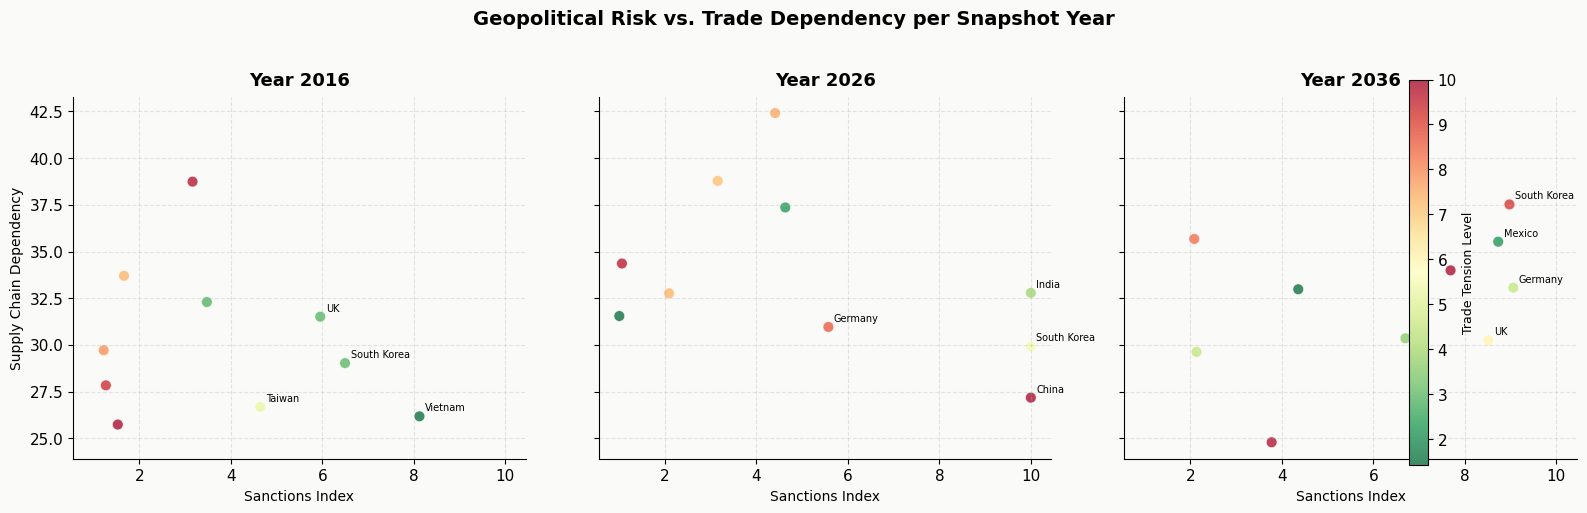

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle(
    "Geopolitical Risk vs. Trade Dependency per Snapshot Year",
    fontsize=14, fontweight="bold", y=1.02
)

for ax, yr in zip(axes, SNAPSHOT_YEARS):

    # Average sanctions risk per country in this year
    geo_yr = (df_geo[df_geo["Year"] == yr]
              .groupby("Country")[["Sanctions_Index", "Trade_Tension_Level"]]
              .mean()
              .reset_index())

    # Average supply-chain dependency (average across all trade partners)
    trade_yr = (df_trade[df_trade["Year"] == yr]
                .groupby("Importing_Country")["Supply_Chain_Dependency"]
                .mean()
                .reset_index()
                .rename(columns={"Importing_Country": "Country"}))

    merged = geo_yr.merge(trade_yr, on="Country", how="inner")

    sc = ax.scatter(
        merged["Sanctions_Index"],
        merged["Supply_Chain_Dependency"],
        c=merged["Trade_Tension_Level"],
        cmap="RdYlGn_r",
        s=60, alpha=0.75, edgecolors="white", linewidths=0.5
    )

    # Label top-risk outliers (high sanction + high dependency)
    top = merged.nlargest(4, "Sanctions_Index")
    for _, row in top.iterrows():
        ax.annotate(row["Country"],
                    (row["Sanctions_Index"], row["Supply_Chain_Dependency"]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")

    ax.set_title(f"Year {yr}", pad=8)
    ax.set_xlabel("Sanctions Index")

axes[0].set_ylabel("Supply Chain Dependency")

# Shared colorbar (represents Trade Tension Level)
cbar = fig.colorbar(sc, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Trade Tension Level", fontsize=9)

plt.tight_layout()
plt.savefig("chart3_geopolitical_vs_dependency.png", dpi=150, bbox_inches="tight")
plt.show()

### VI. Regional Superstar Potential

To define the most potential, we combined score of:
1. global market share growth trajectory (from production dataset)
2. AI chip production growth
3. low supply disruption risk (inverted)

Regions that score high on all three are poised to dominate the future market

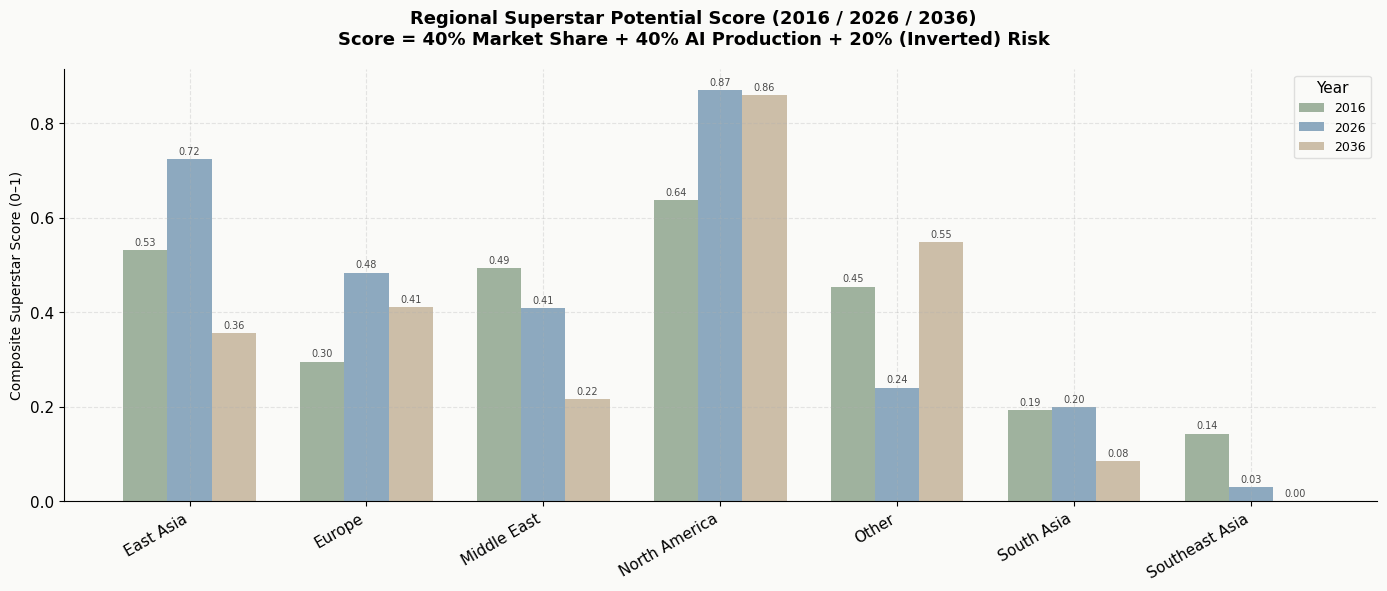

In [55]:
# Step A: Get market share by country aggregated to region (proxy mapping)
COUNTRY_TO_REGION = {
    "USA": "North America", "Canada": "North America",
    "Taiwan": "East Asia", "South Korea": "East Asia",
    "Japan": "East Asia", "China": "East Asia",
    "Netherlands": "Europe", "Germany": "Europe",
    "UK": "Europe", "France": "Europe",
    "India": "South Asia", "Malaysia": "Southeast Asia",
    "Singapore": "Southeast Asia", "Vietnam": "Southeast Asia",
    "Israel": "Middle East",
}

df_prod["Region"] = df_prod["Country"].map(COUNTRY_TO_REGION).fillna("Other")

# Step B: Compute composite score per region for each snapshot year (2016 / 2026/ 2036)
records = []
for yr in SNAPSHOT_YEARS:

    # Market share (mean across companies in region)
    share = (df_prod[df_prod["Year"] == yr]
             .groupby("Region")["Global_Market_Share"].mean())

    # AI chip production (sum)
    ai_prod = (df_prod[df_prod["Year"] == yr]
               .groupby("Region")["AI_Chip_Production"].sum() / 1e9)

    # Supply disruption (lower is better -> invert)
    risk = (df_supply[df_supply["Year"] == yr]
            .groupby("Region")["Supply_Disruption_Index"].mean())

    # Normalize each metric 0–1 within year before combining
    def norm(s):
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 0 else s * 0

    all_regions = share.index.union(ai_prod.index).union(risk.index)
    share   = share.reindex(all_regions, fill_value=0)
    ai_prod = ai_prod.reindex(all_regions, fill_value=0)
    risk    = risk.reindex(all_regions, fill_value=5)

    score = norm(share) * 0.40 + norm(ai_prod) * 0.40 + (1 - norm(risk)) * 0.20
    for region, val in score.items():
        records.append({"Year": yr, "Region": region, "Superstar_Score": val})

superstar_df = pd.DataFrame(records)

# Step C: Plot grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle(
    "Regional Superstar Potential Score (2016 / 2026 / 2036)\n"
    "Score = 40% Market Share + 40% AI Production + 20% (Inverted) Risk",
    fontsize=13, fontweight="bold"
)

regions = superstar_df["Region"].unique()
n_regions = len(regions)
x = np.arange(n_regions)
year_colors = [MORANDI["sage"], MORANDI["dusty_blue"], MORANDI["warm_sand"]]
bar_w = 0.25

for i, (yr, color) in enumerate(zip(SNAPSHOT_YEARS, year_colors)):
    vals = [superstar_df[(superstar_df["Year"] == yr) &
                         (superstar_df["Region"] == r)]["Superstar_Score"].values
            for r in regions]
    vals = [v[0] if len(v) else 0 for v in vals]
    bars = ax.bar(x + i * bar_w, vals, bar_w, label=str(yr),
                  color=color, alpha=0.85)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", fontsize=7, color=MORANDI["charcoal"])

ax.set_xticks(x + bar_w)
ax.set_xticklabels(regions, rotation=30, ha="right")
ax.set_ylabel("Composite Superstar Score (0–1)")
ax.legend(title="Year")
plt.tight_layout()
plt.savefig("chart4_regional_superstar.png", dpi=150, bbox_inches="tight")
plt.show()

### VII. AI Chip Revenue vs. AI GPU Demand over Time

Goal:
1. to find out the revenue growth alongside GPU demand growth
2. validate the market is monetizing AI hardware effectively \

*** IF a divergence (demand rising faster than revenue) may signal pricing pressure or supply bottlenecks (potentially)

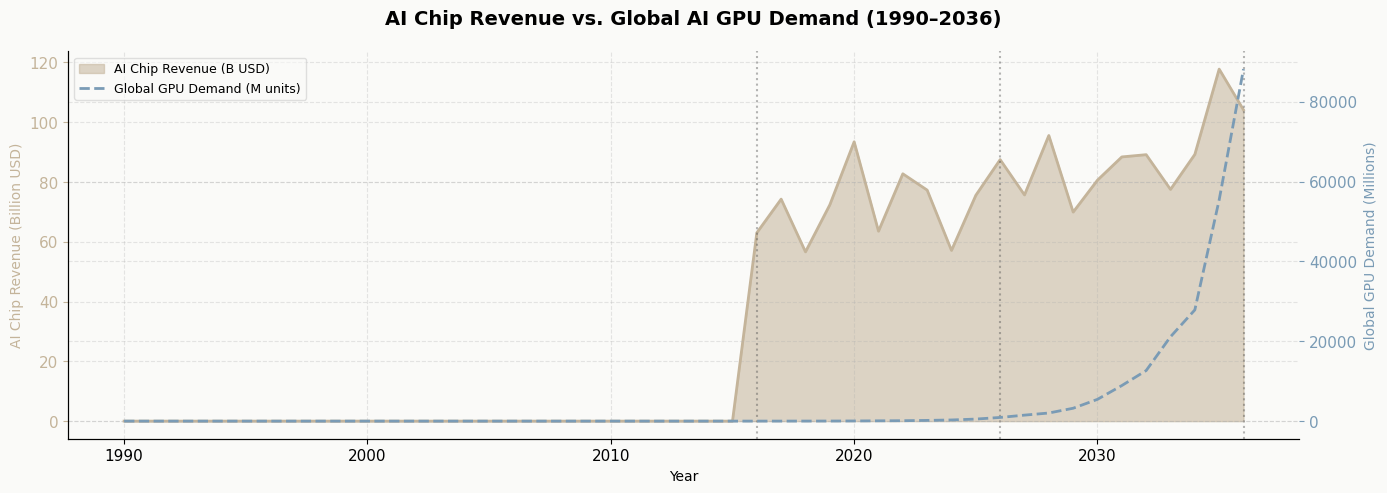

In [57]:
# Global AI GPU demand (sum across all countries per year)
ai_demand_global = df_ai.groupby("Year")["AI_GPU_Demand"].sum().reset_index()
ai_demand_global.columns = ["Year", "Global_GPU_Demand"]

# Merge with market economics
merged_ai = df_market.merge(ai_demand_global, on="Year", how="inner")

fig, ax1 = plt.subplots(figsize=(14, 5))
fig.suptitle(
    "AI Chip Revenue vs. Global AI GPU Demand (1990–2036)",
    fontsize=14, fontweight="bold"
)

ax2 = ax1.twinx()

ax1.fill_between(merged_ai["Year"],
                 merged_ai["AI_Chip_Revenue"] / 1e9,
                 color=MORANDI["warm_sand"], alpha=0.55, label="AI Chip Revenue (B USD)")
ax1.plot(merged_ai["Year"],
         merged_ai["AI_Chip_Revenue"] / 1e9,
         color=MORANDI["warm_sand"], linewidth=2)

ax2.plot(merged_ai["Year"],
         merged_ai["Global_GPU_Demand"] / 1e6,
         color=MORANDI["dusty_blue"], linewidth=2, linestyle="--",
         label="Global GPU Demand (M units)")

for yr in SNAPSHOT_YEARS:
    ax1.axvline(yr, color=MORANDI["charcoal"], linestyle=":", alpha=0.4)

ax1.set_xlabel("Year")
ax1.set_ylabel("AI Chip Revenue (Billion USD)", color=MORANDI["warm_sand"])
ax2.set_ylabel("Global GPU Demand (Millions)", color=MORANDI["dusty_blue"])
ax1.tick_params(axis="y", colors=MORANDI["warm_sand"])
ax2.tick_params(axis="y", colors=MORANDI["dusty_blue"])

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("chart5_ai_revenue_vs_demand.png", dpi=150, bbox_inches="tight")
plt.show()

### VIII. Technology Node Innovation: R&D Spend vs Performance

Goal: tracking R&D spend against AI chip performance \
Determine: whether investment is translating into real-world gains or hitting diminishing returns

Formula: \
Smaller node sizes (nm) = more transistors = better AI performance

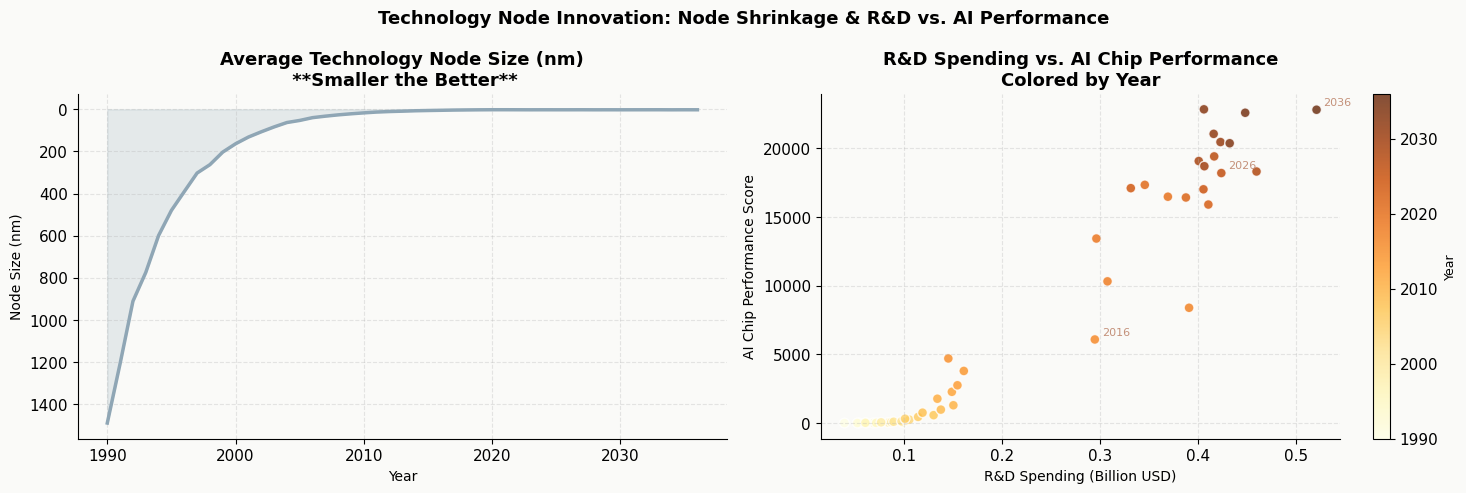

In [61]:
# Node size stored as string, convert to numeric (take first number)
df_prod["Node_nm"] = (df_prod["Technology_Node_nm"]
                      .str.extract(r"(\d+\.?\d*)")[0]
                      .astype(float))

# Aggregate: mean node size per year (global progress)
node_trend = df_prod.groupby("Year")["Node_nm"].mean().reset_index()

# R&D spend & AI chip performance per year from tech innovation dataset
tech_trend = df_tech.groupby("Year")[["RD_Spending_USD", "AI_Chip_Performance"]].mean().reset_index()

merged_tech = node_trend.merge(tech_trend, on="Year", how="inner")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    "Technology Node Innovation: Node Shrinkage & R&D vs. AI Performance",
    fontsize=13, fontweight="bold"
)

# Left: Node size over time (shrinking = progress)
axes[0].plot(merged_tech["Year"], merged_tech["Node_nm"],
             color=MORANDI["steel"], linewidth=2.5)
axes[0].fill_between(merged_tech["Year"], merged_tech["Node_nm"],
                     color=MORANDI["steel"], alpha=0.2)
axes[0].set_title("Average Technology Node Size (nm)\n **Smaller the Better**")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Node Size (nm)")
axes[0].invert_yaxis()   # flip so improvement goes upward visually

# Right: R&D spend vs AI performance (scatter colored by year)
sc = axes[1].scatter(
    merged_tech["RD_Spending_USD"] / 1e9,
    merged_tech["AI_Chip_Performance"],
    c=merged_tech["Year"],
    cmap="YlOrBr",
    s=50, alpha=0.8, edgecolors="white"
)
for yr in SNAPSHOT_YEARS:
    row = merged_tech[merged_tech["Year"] == yr]
    if not row.empty:
        axes[1].annotate(str(yr),
            (row["RD_Spending_USD"].values[0] / 1e9,
             row["AI_Chip_Performance"].values[0]),
            fontsize=8, xytext=(5, 3), textcoords="offset points",
            color=MORANDI["blush"])

cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label("Year", fontsize=9)
axes[1].set_title("R&D Spending vs. AI Chip Performance\nColored by Year")
axes[1].set_xlabel("R&D Spending (Billion USD)")
axes[1].set_ylabel("AI Chip Performance Score")

plt.tight_layout()
plt.savefig("chart6_tech_innovation.png", dpi=150, bbox_inches="tight")
plt.show()

### IX. Trade Balance & Export Flow between Key Players (snapyshot year - 2016 / 2026 / 2036)

A country with large positive trade balance exports far more chips than it imports (net supplier to the world) \
Comparing 2016/2026/2036 shows whether dependency patterns are shifting (new exporters emerging)

Formula: \
Negative balance = net dependent

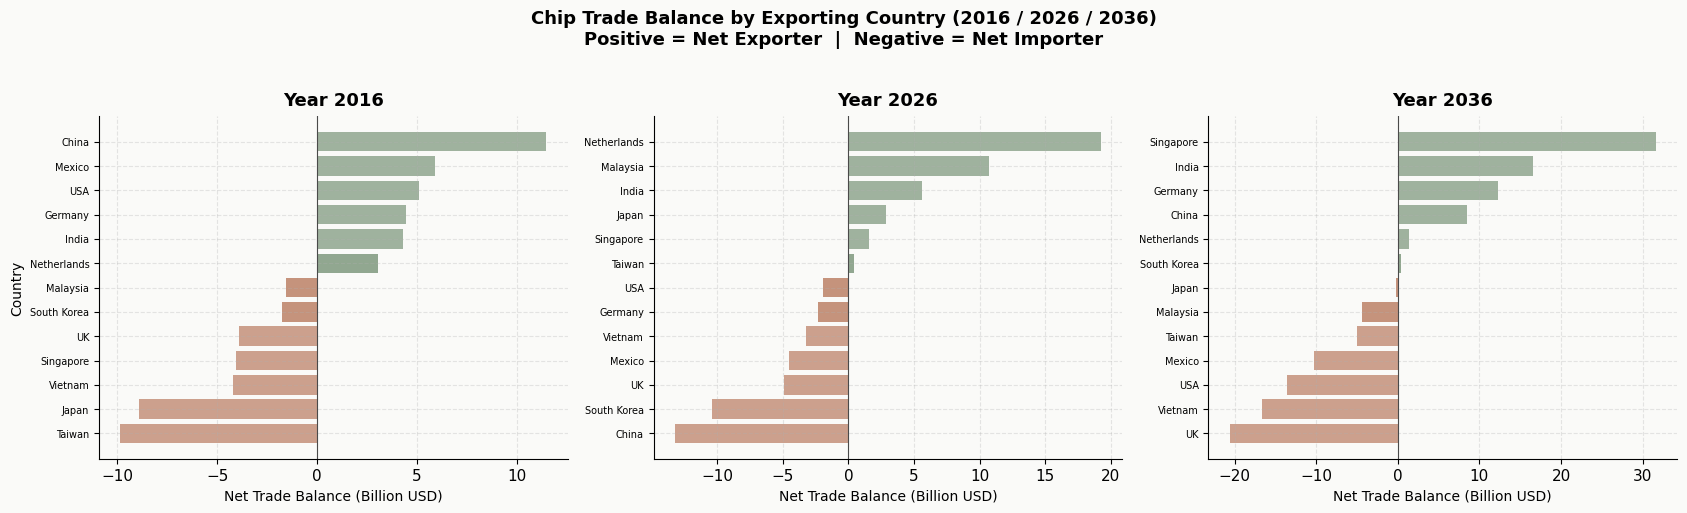

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)
fig.suptitle(
    "Chip Trade Balance by Exporting Country (2016 / 2026 / 2036)\n"
    "Positive = Net Exporter  |  Negative = Net Importer",
    fontsize=13, fontweight="bold", y=1.02
)

for ax, yr in zip(axes, SNAPSHOT_YEARS):

    trade_yr = df_trade[df_trade["Year"] == yr]

    # Net balance per country (as exporter minus as importer)
    export_bal = trade_yr.groupby("Exporting_Country")["Trade_Balance"].sum()
    import_bal = trade_yr.groupby("Importing_Country")["Trade_Balance"].sum()
    net_balance = export_bal.sub(import_bal, fill_value=0).sort_values()

    # Keep top and bottom 8 for readability
    top8    = net_balance.nlargest(8)
    bottom8 = net_balance.nsmallest(8)
    display = pd.concat([bottom8, top8]).sort_values()

    colors = [MORANDI["blush"] if v < 0 else MORANDI["sage"] for v in display.values]
    ax.barh(display.index, display.values / 1e9, color=colors, alpha=0.85)
    ax.axvline(0, color=MORANDI["charcoal"], linewidth=0.8)
    ax.set_title(f"Year {yr}", pad=8)
    ax.set_xlabel("Net Trade Balance (Billion USD)")
    ax.tick_params(axis="y", labelsize=7)

axes[0].set_ylabel("Country")
plt.tight_layout()
plt.savefig("chart7_trade_balance.png", dpi=150, bbox_inches="tight")
plt.show()

### X. Market Economics Dashboard (all years)

A single-page view of
1. global revenue
2. growth rate
3. chip price index

gives executives a macro lens to spot boom/bust cycles and long-run trends


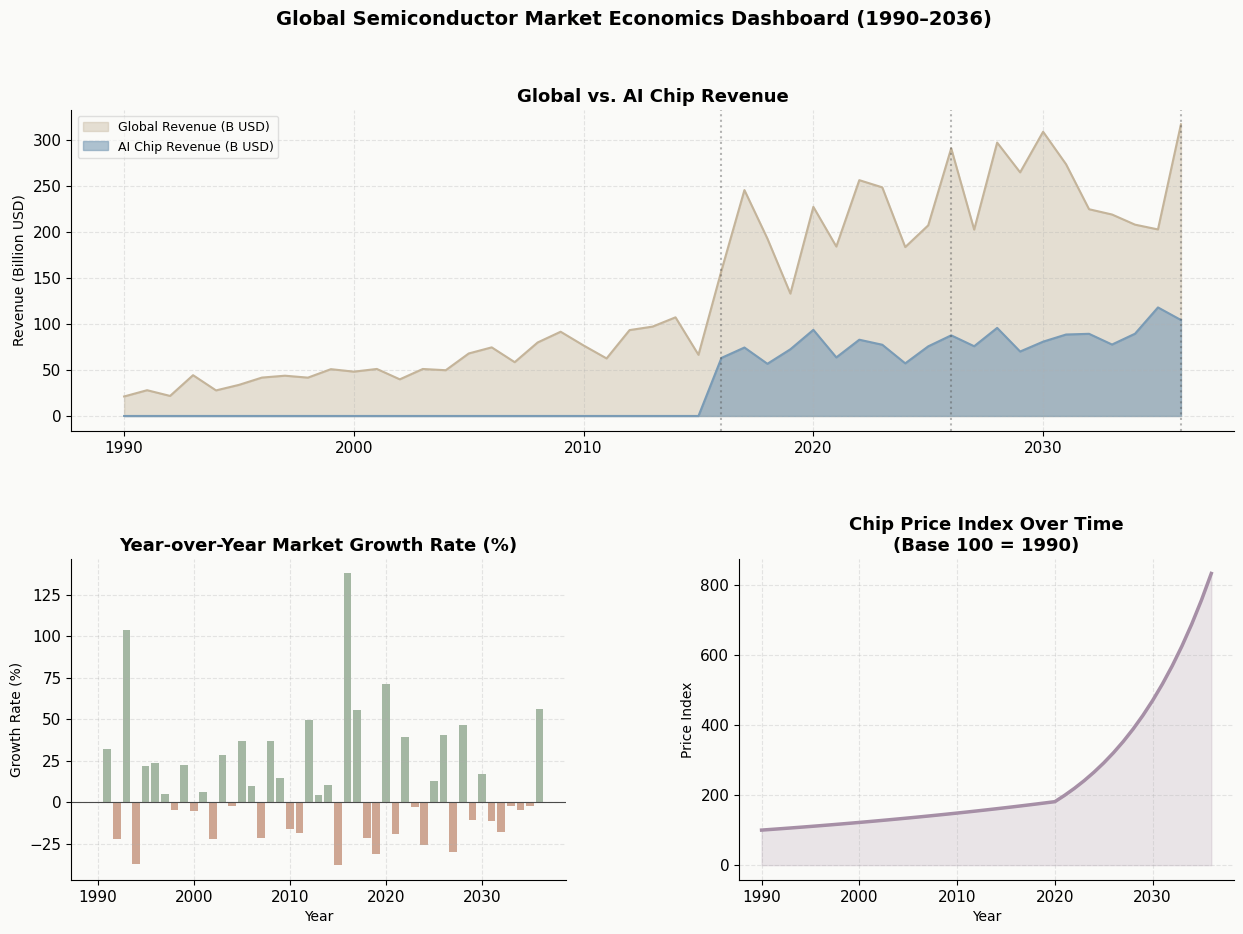

In [65]:
fig = plt.figure(figsize=(15, 10))
fig.suptitle(
    "Global Semiconductor Market Economics Dashboard (1990–2036)",
    fontsize=14, fontweight="bold"
)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax_rev   = fig.add_subplot(gs[0, :])   # full width — revenue
ax_growth= fig.add_subplot(gs[1, 0])
ax_price = fig.add_subplot(gs[1, 1])

# --- Total Revenue vs AI chip revenue
ax_rev.fill_between(df_market["Year"],
                    df_market["Global_Semiconductor_Revenue"] / 1e9,
                    color=MORANDI["warm_sand"], alpha=0.4, label="Global Revenue (B USD)")
ax_rev.fill_between(df_market["Year"],
                    df_market["AI_Chip_Revenue"] / 1e9,
                    color=MORANDI["dusty_blue"], alpha=0.6, label="AI Chip Revenue (B USD)")
ax_rev.plot(df_market["Year"], df_market["Global_Semiconductor_Revenue"] / 1e9,
            color=MORANDI["warm_sand"], linewidth=1.5)
ax_rev.plot(df_market["Year"], df_market["AI_Chip_Revenue"] / 1e9,
            color=MORANDI["dusty_blue"], linewidth=1.5)
for yr in SNAPSHOT_YEARS:
    ax_rev.axvline(yr, color=MORANDI["charcoal"], linestyle=":", alpha=0.4)
ax_rev.set_title("Global vs. AI Chip Revenue")
ax_rev.set_ylabel("Revenue (Billion USD)")
ax_rev.legend(loc="upper left")

# --- Market growth rate (YoY %)
ax_growth.bar(df_market["Year"], df_market["Market_Growth_Rate"],
              color=[MORANDI["sage"] if v >= 0 else MORANDI["blush"]
                     for v in df_market["Market_Growth_Rate"]],
              alpha=0.8)
ax_growth.axhline(0, color=MORANDI["charcoal"], linewidth=0.8)
ax_growth.set_title("Year-over-Year Market Growth Rate (%)")
ax_growth.set_ylabel("Growth Rate (%)")
ax_growth.set_xlabel("Year")

# --- Chip price index
ax_price.plot(df_market["Year"], df_market["Chip_Price_Index"],
              color=MORANDI["mauve"], linewidth=2.5)
ax_price.fill_between(df_market["Year"], df_market["Chip_Price_Index"],
                      color=MORANDI["mauve"], alpha=0.2)
ax_price.set_title("Chip Price Index Over Time\n(Base 100 = 1990)")
ax_price.set_ylabel("Price Index")
ax_price.set_xlabel("Year")

plt.savefig("chart8_market_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

### XI. Cross-dataset Correlation Heatmap (2036)

Combining signals from all 7 datasets into a single correlation matrix
surfaces hidden relationships — e.g., does higher geopolitical risk correlate
with lower production capacity? Does R&D spend predict market share?
2036 is chosen as the mid-point forecast year for this analysis.


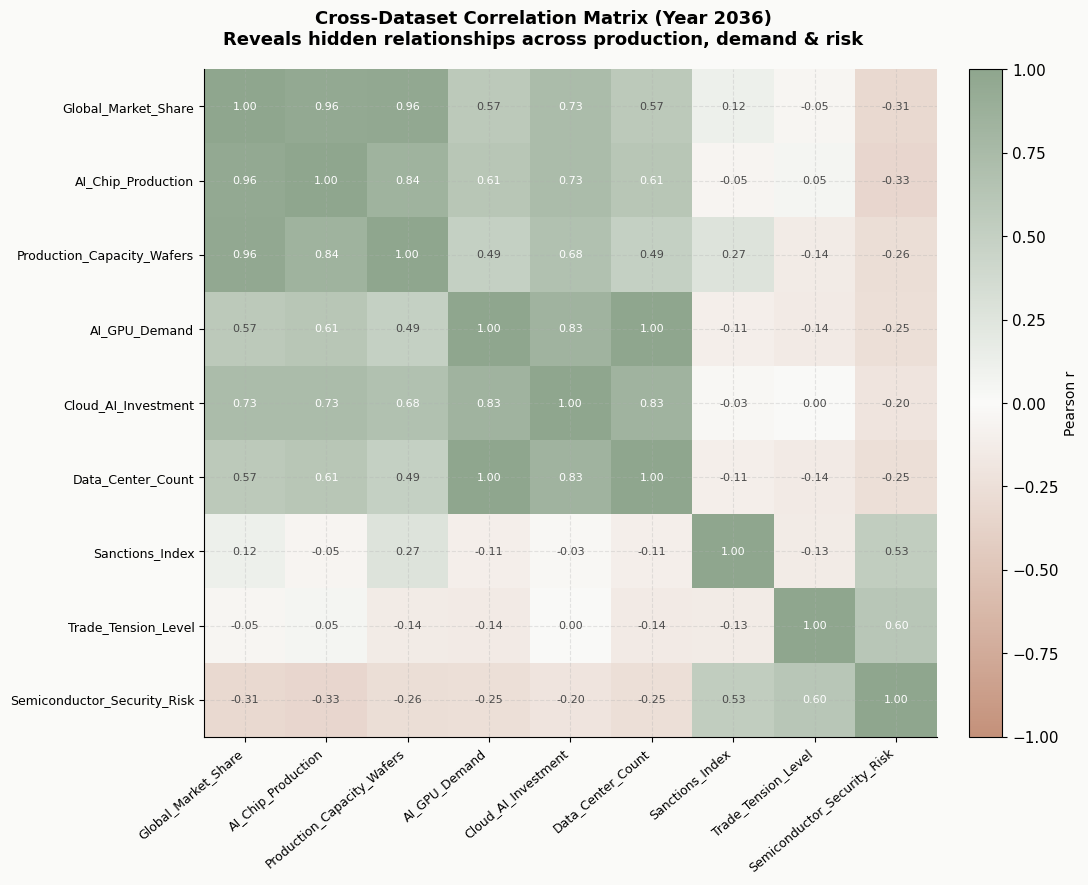

In [69]:
FOCUS_YEAR = 2036

# Aggregate each dataset to country level for 2036
prod_2036  = (df_prod[df_prod["Year"] == FOCUS_YEAR]
              .groupby("Country")[["Global_Market_Share", "AI_Chip_Production",
                                   "Production_Capacity_Wafers"]].mean())

ai_2036    = (df_ai[df_ai["Year"] == FOCUS_YEAR]
              .groupby("Country")[["AI_GPU_Demand", "Cloud_AI_Investment",
                                   "Data_Center_Count"]].mean())

geo_2036   = (df_geo[df_geo["Year"] == FOCUS_YEAR]
              .groupby("Country")[["Sanctions_Index", "Trade_Tension_Level",
                                   "Semiconductor_Security_Risk"]].mean())

tech_2036  = (df_tech[df_tech["Year"] == FOCUS_YEAR]
              .groupby("Company")[["RD_Spending_USD", "AI_Chip_Performance",
                                   "Energy_Efficiency"]].mean())

# Join production + ai demand + geopolitical (all country-indexed)
combined = prod_2036.join(ai_2036, how="outer").join(geo_2036, how="outer").dropna()

corr = combined.corr()

fig, ax = plt.subplots(figsize=(11, 9))
fig.suptitle(
    f"Cross-Dataset Correlation Matrix (Year {FOCUS_YEAR})\n"
    "Reveals hidden relationships across production, demand & risk",
    fontsize=13, fontweight="bold"
)

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list(
    "morandi_div",
    [MORANDI["blush"], "#FAFAF8", MORANDI["sage"]]
)

im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")

labels = corr.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

# Annotate cells with correlation value
for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr.values[i, j]
        text_color = "white" if abs(val) > 0.6 else MORANDI["charcoal"]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color=text_color)

plt.tight_layout()
plt.savefig("chart9_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### XII. Risk Decomposition for Top Production Countries (2026 vs 2036)

Countries with the highest production share, break down by 4 risk components:
1. natural Disaster
2. energy
3. water
4. factory shutdown

Goal: whether those countries' dominance is structurally safe or built on a fragile foundation, critical for supply chain resilience planning


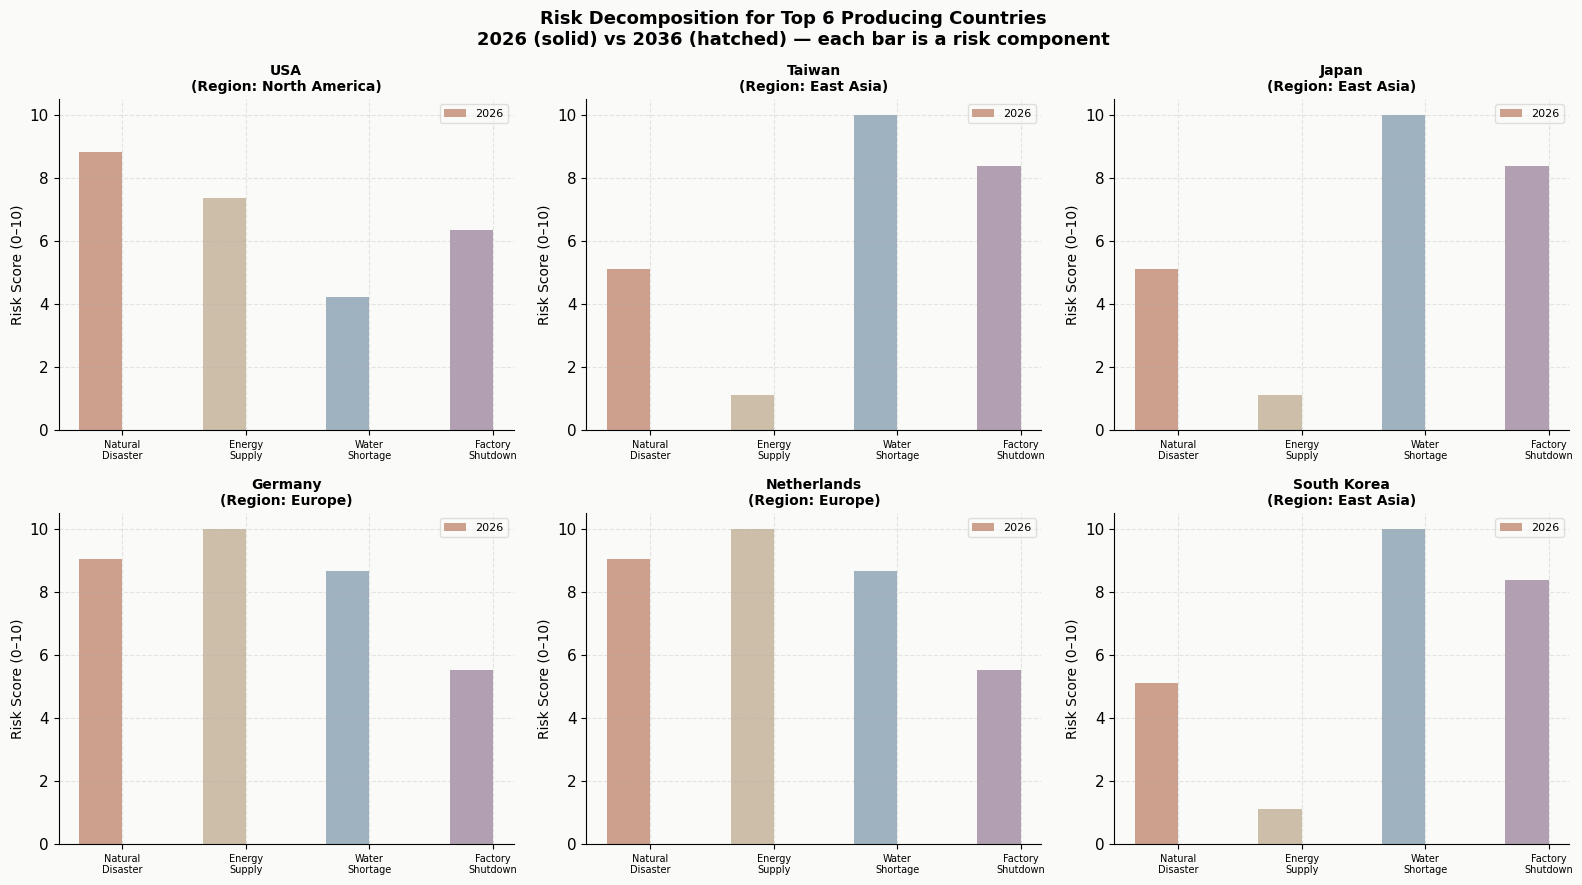

In [71]:
# Identify top 6 producing countries by AI_Chip_Production in 2026
top_producers = (df_prod[df_prod["Year"] == 2026]
                 .groupby("Country")["AI_Chip_Production"]
                 .sum()
                 .nlargest(6)
                 .index.tolist())

# Map them to regions for the supply disruption dataset
risk_cols = ["Natural_Disaster_Risk", "Energy_Supply_Risk",
             "Water_Shortage_Risk", "Factory_Shutdown_Risk"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    "Risk Decomposition for Top 6 Producing Countries\n"
    "2026 (solid) vs 2036 (hatched) — each bar is a risk component",
    fontsize=13, fontweight="bold"
)
axes = axes.flatten()

# Color one risk component with a distinct Morandi color
risk_colors = [MORANDI["blush"], MORANDI["warm_sand"],
               MORANDI["steel"], MORANDI["mauve"]]

for ax, country in zip(axes, top_producers):
    # Map country → region
    region = COUNTRY_TO_REGION.get(country, "Other")

    for yr, hatch, alpha in [(2026, "", 0.85), (2046, "//", 0.55)]:
        sub = df_supply[(df_supply["Year"] == yr) & (df_supply["Region"] == region)]
        if sub.empty:
            continue
        values = sub[risk_cols].mean().values
        x_pos  = np.arange(len(risk_cols))
        bars = ax.bar(x_pos + (0 if yr == 2026 else 0.35),
                      values, 0.35,
                      color=risk_colors, alpha=alpha, hatch=hatch,
                      label=str(yr))

    ax.set_title(f"{country}\n(Region: {region})", fontsize=10)
    ax.set_xticks(np.arange(len(risk_cols)) + 0.175)
    ax.set_xticklabels(["Natural\nDisaster", "Energy\nSupply",
                        "Water\nShortage", "Factory\nShutdown"],
                       fontsize=7)
    ax.set_ylabel("Risk Score (0–10)")
    ax.set_ylim(0, 10.5)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("chart10_risk_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()


### Key Findings

In [68]:
print("Analytical Findings Summary")

# Finding 1: Demand vs Production Gap
print("\n #1 — Demand vs Production Gap")
for yr in SNAPSHOT_YEARS:
    prod_total = df_prod[df_prod["Year"] == yr]["AI_Chip_Production"].sum()
    dem_total  = df_ai[df_ai["Year"] == yr]["AI_GPU_Demand"].sum()
    # Check if prod_total is zero to avoid division by zero
    if prod_total != 0:
        gap_pct    = (dem_total - prod_total) / prod_total * 100
        print(f"  {yr}: Demand exceeds Production by {gap_pct:+.1f}%")
    else:
        print(f"  {yr}: Production data is zero or missing, cannot calculate gap percentage.")

# Finding 2: Highest disruption region
print("\n #2 - Most Disruption-Prone Region (average 2026–2036)")
avg_risk = (df_supply[df_supply["Year"].isin(SNAPSHOT_YEARS)]
            .groupby("Region")["Supply_Disruption_Index"].mean()
            .sort_values(ascending=False))
print(avg_risk.to_string())

# Finding 3: Top superstar region in 2046
print("\n #3 — Top Superstar Region in 2036")
# Filter for 2046 and ensure Superstar_Score is positive before finding nlargest
top_star_2046 = superstar_df[(superstar_df["Year"] == 2046) & (superstar_df["Superstar_Score"] > 0)].nlargest(3, "Superstar_Score")
if not top_star_2046.empty:
    print(top_star_2046[["Region", "Superstar_Score"]].to_string(index=False))
else:
    print("  No regions found with a positive Superstar Score in 2036.")

# Finding 4: R&D vs performance correlation
corr_val = merged_tech[["RD_Spending_USD", "AI_Chip_Performance"]].corr().iloc[0, 1]
print(f"\n #4 — Correlation: R&D Spending ↔ AI Chip Performance = {corr_val:.3f}")

# Finding 5: Market revenue CAGR (2026→Latest Available Year)
# Identify the last available year in df_market
last_market_year = df_market["Year"].max()

# Ensure 2026 data is available as a starting point
if 2026 in df_market["Year"].values:
    rev_26 = df_market[df_market["Year"] == 2026]["Global_Semiconductor_Revenue"].values[0]

    # Determine the end year for CAGR calculation. Use 2036 if 2046 is not available.
    # The maximum year in df_market is 2036.
    rev_end_year = last_market_year
    rev_end = df_market[df_market["Year"] == rev_end_year]["Global_Semiconductor_Revenue"].values[0]

    # Calculate CAGR only if both revenue values are positive and valid, and there's a valid period.
    if rev_26 > 0 and rev_end > 0 and rev_end_year > 2026:
        years_diff = rev_end_year - 2026
        cagr = (rev_end / rev_26) ** (1/years_diff) - 1
        print(f"\n #5 — Global Revenue CAGR (2026→{rev_end_year}): {cagr*100:.2f}% per year")
        print(f"   2026 Revenue: ${rev_26/1e9:.1f}B  →  {rev_end_year} Revenue: ${rev_end/1e9:.1f}B")
    else:
        print(f"\n #5 — Can't calculate Global Revenue CAGR (2026→{rev_end_year}) due to invalid revenue data or insufficient period.")
else:
    print("\n #5 — Can't calculate Global Revenue CAGR. Data for 2026 not found in df_market.")

Analytical Findings Summary

 #1 — Demand vs Production Gap
  2016: Demand exceeds Production by -50.1%
  2026: Demand exceeds Production by +7895.3%
  2036: Demand exceeds Production by +597843.0%

 #2 - Most Disruption-Prone Region (average 2026–2036)
Region
Europe            7.299855
Southeast Asia    6.984750
Middle East       6.296774
East Asia         6.113447
Other             5.930265
North America     5.918446
South Asia        4.603213

 #3 — Top Superstar Region in 2036
  No regions found with a positive Superstar Score in 2036.

 #4 — Correlation: R&D Spending ↔ AI Chip Performance = 0.967

 #5 — Global Revenue CAGR (2026→2036): 0.86% per year
   2026 Revenue: $290.4B  →  2036 Revenue: $316.5B
